# **Lab 3:** Convolutional Neural Networks

### **IMPORTANT:** For this lab, only questions 10 and above will be graded. You are still encouraged to go through questions 1-9, particularly if you need to review convolutional networks.

# Part 0: Enviornment Setup


For this lab and for the final project, you may find it useful to run your code with access to a sufficient GPU, which may allow your code to run faster.

In [1]:
# Uncomment and run if using Colab!

#import urllib.request
#remote_url = 'https://gist.githubusercontent.com/gabehope/3e574b9d225004ff1a179136c29ef4d5/raw/288949bfc3b768b7603fe4decafbcd589c9a72d5/hw9_support.py'
#with urllib.request.urlopen(remote_url) as remote, open('lab3_support.py', 'w') as local:
#  [local.write(str(line, encoding='utf-8')) for line in remote]


In [12]:
# This is the path that the dataset for this homework will be downloaded to.
# If you are running on the course server or Colab you can keep this line, if you are
# running on a personal computer, you may want to change this location.

from lab3_support import *
data_path = '/tmp/data'
import numpy as np
import matplotlib.pyplot as plt


Using 'cuda' device.


# Part 1: Convolutions

Recall that a *convolution* can be thought of as a moving dot product between a *kernel* vector or matrix and an *input* vector or matrix. (Note: technically the operation we're defining here is a *discrete cross-correlation*, not a convolution, but the names are often used interchangably). In particular, a 1-dimensional convolution is an operation between an input vector $\mathbf{x}$ and a kernel $\mathbf{k}$, such that each entry of the output vector $\mathbf{c}$ is defined by centering $\mathbf{k}$ at an entry of $\mathbf{x}$, multiplying the aligning elements and taking the sum of the results as in the following animation:





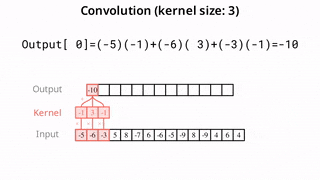

Note that without padding, we only consider locations for the kernel where every entry aligns with an entry from the input, resulting in an output that is shorter than the input.

#### **Q1** (5 Points)

Find the result of taking the convolution of the following input and kernel (by hand), using the approach shown above.

$$\text{Input: } \begin{bmatrix}2 & 3 & -1 & 5 & -2 \end{bmatrix}$$
$$\text{Kernel: } \begin{bmatrix} 1 & 2 & 1 \end{bmatrix}$$

Unfortunately, this notion of "centering" the kernel at each location doesn't work if our kernel is an even size. Instead, we need a general formula. We'll define output $i$ of our convolution to be:

$$\text{Conv}(\mathbf{x}, \mathbf{k})_i = \sum_{j=0}^{s-1} x_{i+j} k_j$$


We'll use the following convention for the size of the input and kernel:
$$ \text{Input size: } d$$
$$ \text{Kernel size: } s$$

#### **Q2** (5 Points)

Looking at the convolution equation above, what is the length of the output in terms of $d$ and $s$? Note that without padding, the length of the output will be determined by the maximum value of $i$, such that $x_{i+j}$ is a valid entry of $x$ for all terms in the summation (i.e. $i+j \leq d$).

$d-s+1$

#### **Q3** (5 Points)

Complete the 1-dimensional convolution function below using the formula for the output length you just defined and the convolution formula. Do not use a convolution function from a Python library such as SciPy or PyTorch.

*Feel free to use Python loops, as we won't actually train with this implementation, so performance doesn't matter!*

In [4]:
def conv1d(sequence, kernel):
    kernel_size = kernel.shape[0]
    sequence_length = sequence.shape[0]
    output_length = sequence_length-kernel_size+1

    output = np.zeros((output_length,))
    
    for i in range(output_length):
        conv = 0
        for j in range(kernel_size-1):
            conv += sequence[i+j]*kernel[j]
        output[i] = conv
    
    return output

Now we'll try out our convolution on a sequence of data! Below, we'll create an arbitrary input sequence and apply a kernel to it using the convolution function we just wrote. If you're curious, try changing the kernel and see how the result changes!

In [5]:
# Create a domain to create our input
x = np.linspace(-5, 5, 25)

# Create an sequence
signal = np.sin(x * 1.5) + np.cos(x / 2) + np.cos(x / 1.3 + 2)

# Create a kernel for our convolution
kernel = np.array([-1, 1, -1])

print(signal)

# Plot the input, kernel and the result of the convolution
f, ax = plt.subplots(1, 3, figsize=(7, 2))
ax[0].plot(signal)
ax[0].set_title('Input')
ax[1].plot(kernel)
ax[1].set_title('Kernel')
ax[2].plot(conv1d(signal, kernel))
ax[2].set_title('Convolved')


NameError: name 'np' is not defined

Now let's define how to compute derivatives of convolutions. We'll start by defining $\mathbf{c} = \text{Conv}(\mathbf{x}, \mathbf{k})$ to be the output of our convolution and $\frac{dL}{d\mathbf{c}}$ to be the gradient of a (scalar) loss with respect to $\mathbf{c}$. We could compute the derivative with respect to each entry in the input $(x_{j})$ or kernel $(k_{j})$ by applying the chain rule using every entry in $\mathbf{c}$, $(C_{i})$ and summing the results:

$$\frac{dL}{dx_{j}} = \sum_{i=0}^{d-1} \frac{dL}{dc_{i}}\frac{dc_{i}}{dx_{j}}$$
$$\frac{dL}{dk_{j}} = \sum_{i=0}^{d-1}  \frac{dL}{dc_{i}}\frac{dc_{i}}{dk_{j}}$$

Note that, because of the convolutional structure, each entry of the output only depends on a few entries of the input. If $c_i$ does not depend on $x_j$, then $\frac{dc_i}{dx_j}$ will be 0. Consider the gradient animation below.


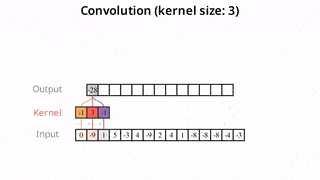

A more efficient way to think about computing these derivatives is to consider the gradient updates that correspond to each update of our output. If we update:

$$c_{i} \longleftarrow c_{i} + x_{i+j}\ k_{j}$$
Then in our backward pass of automatic differentiation, we will need to update:
$$\frac{dL}{dx_{i+j}} \longleftarrow \frac{dL}{dx_{i+j}} +\frac{dL}{dc_{i}} \frac{dc_i}{dx_{i+j}}$$
$$\frac{dL}{dk_{j}} \longleftarrow \frac{dL}{dk_{j}} +\frac{dL}{dc_{i}} \frac{dc_i}{dk_{j}}$$

#### **Q4** (5 Points)

Modify your `conv1d` function to compute the gradient of the loss with respect to both the input $(\mathbf{x})$ and the kernel $(\mathbf{k})$. The function will now take an additional argument that specifies $\frac{dL}{d\mathbf{c}}$, the gradient of the loss $(L)$ with respect the output of the convolution $(\mathbf{c})$.

***Hint:** If you used loops to implement `conv1d` you can keep the same structure, each time you would update an entry of the output $\mathbf{c}$, update the appropriate entries of $\frac{dL}{dx_{i+j}}$ and $\frac{dL}{dk_{j}}$ instead as shown above.*

In [ ]:
def conv1d_backward(sequence, kernel, dloss_doutput):
    kernel_size = kernel.shape[0]
    sequence_length = sequence.shape[0]
    output_length = dloss_doutput.shape[0]

    dloss_dsequence = np.zeros_like(sequence)
    dloss_dkernel = np.zeros_like(kernel)

    ## YOUR CODE HERE

    return dloss_dsequence, dloss_dkernel

A 2-dimensional convolution generalizes the idea of a convolution to matrices, as shown in the following animation ([credit](https://arxiv.org/abs/1603.07285)).

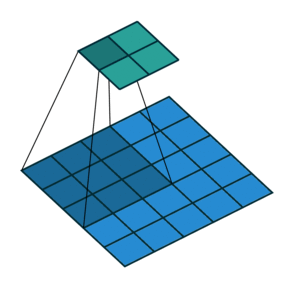

In this case we assume both the input $\mathbf{X}$ and kernel $\mathbf{K}$ are matricies of size $(d \times e)$ and $(s \times s)$ respectively:
$$\text{Input }\mathbf{X}: d \times e \text{ matrix}$$
$$\text{Kernel }\mathbf{K}: s \times s \text{ matrix}$$

*Note: we're assuming for simplcity that $\mathbf{K}$ is square, but this need not be the case in general.*

In this case, we move our 2-dimensional kernel to every possible location in the input and once again multiply corresponding elements, taking the sum. We can summarize this in a similar equation:

$$\text{Conv}(\mathbf{X}, \mathbf{K})_{r,c} =  \sum_{i=0}^{s-1}\sum_{j=0}^{s-1} X_{r+i,c+j}\ K_{i,j}$$

#### **Q5** (5 Points)

Complete the following implementation of a 2-dimensional convolution. using the equation above. As before, you'll need to determine the correct output size first.

*Once again, performance doesn't matter here*

In [ ]:
def conv2d(image, kernel):
    kernel_size = kernel.shape[0]
    image_height, image_width = image.shape[0], image.shape[1]
    output_height = # YOUR CODE HERE
    output_width = # YOUR CODE HERE

    output = np.zeros((output_height, output_width))
    ## YOUR CODE HERE

    return output

Let's try out our `conv2d` function on an image. As we've used in previous homeworks, we can use PyTorch to load a variety of real datasets. For image datasets, these are available in the `torchvision` library. We can download the MNIST dataset of number images that we've used before with the following code:

In [ ]:
import torchvision
data = torchvision.datasets.MNIST(data_path,       # Specify where to store the data
                                  download=True,   # Whether to download the data if we don't have it
                                  train=True       # Download the training set (False will download the validation set)
                                  )
print(data[0])

We see that in the above if we take an observation from this dataset we get a tuple of an image and a corresponding label. The image is given as an object from the Pillow library (`PIL`).

In [ ]:
data[0][0]

We can convert Pillow images to torch tensors using a `torchvision.transforms.ToTensor` object, or we can pass such an object directly to the dataset class to transform our data automatically.

In [ ]:
# Create a transform object
transform = torchvision.transforms.ToTensor()

# Apply the transform to the first image in the dataset (ignoring the label)
image = transform(data[0][0])
print('Converted image type:', type(image))

# Give the transform directly to the MNIST object
data = torchvision.datasets.MNIST(data_path, transform=transform)
print('Automatically converted image type:', type(data[0][0]))
print('Image shape:', data[0][0].shape)


If we look at the shape of an image, we see that it has height and width dimensions, but also an extra dimension. This is the *color channel dimension*. Since these are greyscale images with only a single color channel we'll get rid of it for now.

In [ ]:
# Take just the height and width dimensions of our image
image = data[0][0][0]
image.shape

Fianlly let's apply a few different kernels to the image and visualize the results.

In [ ]:
# Create an edge detection kernel
kernel = np.array([[ 1,  1,  1],
                   [ 0,  0,  0],
                   [-1, -1, -1]])

# Create the axes for our plots
f, ax = plt.subplots(2, 4, figsize=(8, 4))
ax[0, 0].imshow(image, cmap='Greys_r')
ax[0, 0].set_title('Image')

# Apply our convolution and plot the result
output = conv2d(image, kernel)
ax[0, 1].imshow(output, cmap='Greys_r')
ax[0, 1].set_title('Vertical edges')
ax[1, 1].imshow(kernel, cmap='Greys_r')

# Apply our transposed convolution and plot the result
output = conv2d(image, kernel.T)
ax[0, 2].imshow(output, cmap='Greys_r')
ax[0, 2].set_title('Horizontal edges')
ax[1, 2].imshow(kernel.T, cmap='Greys_r')

# Apply a kernel of all 1s to blur the image
output = conv2d(image, np.ones_like(kernel))
ax[0, 3].imshow(output, cmap='Greys_r')
ax[0, 3].set_title('Blur')
ax[1, 3].imshow(np.ones_like(kernel), cmap='Greys_r')


A common extension to convolutions is to *pad* the input with zeros before applying the convolution operation. This allows for outputs that match the size of the input even for large kernels. In the 1-dimensional case, a convolution with padding can be visualized as follows:





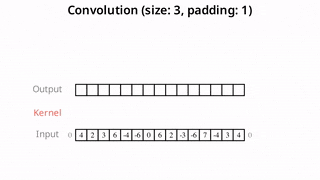

In the 2-dimensional case, it can be visualized as:



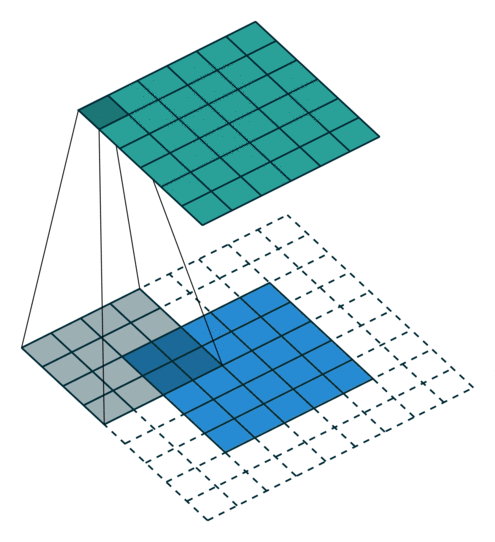

#### **Q6** (5 Points)

Modify your `conv2d` function to take an additional argument `padding` that specifies the number of 0s to add before the first element and after the last element of each dimension before applying the convolution. For example:
$$\text{Padding = 1: }\quad \begin{bmatrix} 2 & 5 \\ -1 & 3 \end{bmatrix} \longrightarrow \begin{bmatrix} 0 & 0 & 0 & 0 \\ 0 & 2 & 5 & 0 \\ 0 & -1 & 3 & 0 \\ 0 & 0 & 0 & 0 \\\end{bmatrix} $$
$$\text{Padding = 2: }\quad \begin{bmatrix} 2 & 5 \\ -1 & 3 \end{bmatrix} \longrightarrow \begin{bmatrix}0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 2 & 5 & 0 & 0 \\ 0 & 0 & -1 & 3 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0\end{bmatrix} $$

***Hint:** Make sure to account for the change in the output shape!*

In [ ]:
def conv2d(image, kernel, padding=0):
    kernel_size = kernel.shape[0]
    image_height, image_width = image.shape[0], image.shape[1]
    output_height = # YOUR CODE HERE
    output_width = # YOUR CODE HERE

    output = np.zeros((output_height, output_width))
    ## YOUR CODE HERE

    return output

Let's visualize the same convolution with and without padding.

In [ ]:
# Create an edge detection kernel
kernel = np.array([[ 1,  1,  1],
                   [ 0,  0,  0],
                   [-1, -1, -1]])

# Take just the height and width dimensions of our image
image = data[0][0][0]

# Create the axes for our plots
f, ax = plt.subplots(1, 3,)
ax[0].imshow(image, cmap='Greys_r')
ax[0].set_title('Image')

# Apply our convolution with no padding and plot the result
output_0 = conv2d(image, kernel, padding=0)
ax[1].imshow(output_0, cmap='Greys_r')
ax[1].set_title('Padding=0')

# Apply our convolution with a padding of 10 and plot the result
output_10 = conv2d(image, kernel, padding=10)
ax[2].imshow(output_10, cmap='Greys_r')
ax[2].set_title('Padding=10')

While it is convinient to think of images as being matrices, as we've seen, color images actually have 3 values at each location! A red value, a green value as a blue value as shown below. We call these the color *channels*.

In [ ]:
import PIL # Pillow
# Load an image
image = np.array(PIL.Image.open('astronaut.jpg'))[..., :3]

# If you're in Colab, you can use the commented line below to load the same image.
#image = (skimage.transform.resize(skimage.data.astronaut(), (128, 128, 3)) * 255).astype(int)

# Plot the color image
f, ax = plt.subplots(1, 4, figsize=(8, 3))
ax[0].imshow(image)
ax[0].set_title('Image')

# Plot each color channel separately
ax[1].imshow(image[..., 0], cmap='Greys_r')
ax[1].set_title('Red channel')
ax[2].imshow(image[..., 1], cmap='Greys_r')
ax[2].set_title('Green channel')
ax[3].imshow(image[..., 2], cmap='Greys_r')
ax[3].set_title('Blue channel')

In PyTorch, we'll represent an image with multiple channels as a $\text{Channels (c)} \times \text{Height (h)} \times \text{Width (w)}$ tensor. *Note: this is different from many other libraries, which put the channel dimension last!*. We therefore have a vector, rather than a scalar at each position in the image.

For a 2-dimensional convolution applied to an image with multiple channels, our kernel will also need to have a matching number of channels. In this case, at each step of our convolution, we'll compute a dot product between two channel vectors rather than two scalars.

$$\text{Conv}(\mathbf{X}, \mathbf{K})_{r,c} =  \sum_{i=0}^{s-1}\sum_{j=0}^{s-1}\sum_{l=0}^{c-1} X_{l, r+i,c+j}\ K_{l, i,j} = \sum_{i=0}^{s-1}\sum_{j=0}^{s-1} X_{:, r+i,c+j}^T\ K_{:, i,j}$$

The following animation shown what this looks like for a 1-dimensional convolution.

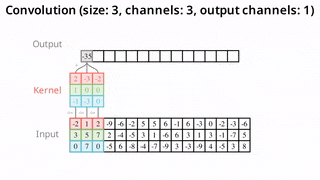

#### **Q7** (5 Points)

Modify your (original or padded) `conv2d` function to accept 2 *3-dimensional tensors* with the following shapes:

$$\text{Input: }\quad \text{Channels (c)} \times \text{Height (h)} \times \text{Width (w)}$$
$$\text{Kernel: }\quad \text{Channels (c)} \times \text{Size (s)} \times \text{Size (s)}$$

The result should be a *2-dimensional matrix*, such that each entry follows the equation above.

In [ ]:
def conv2d(image, kernel, padding=0):
    kernel_size = kernel.shape[-1]
    channels, image_height, image_width = image.shape[0], image.shape[1], image.shape[2]
    output_height = # YOUR CODE HERE
    output_width = # YOUR CODE HERE

    output = np.zeros((output_height, output_width))

    return output

Let's try applying using our convolution function on a color image! Below we'll load an image using the Python Pillow library and use our function to compute a convolution, using an *edge detection* kernel.

In [ ]:
import PIL # Pillow

# Create an edge detection kernel
kernel = np.array([[ 1,  1,  1],
                   [ 0,  0,  0],
                   [-1, -1, -1]])
# Repeat it for the red, green and blue channels
kernel_vertical = np.stack([kernel, kernel, kernel])
# Create a transposed version as well
kernel_horizontal = np.stack([kernel.T, kernel.T, kernel.T])

# Load an image and convert it to a numpy array
image = np.array(PIL.Image.open('astronaut.jpg'))[..., :3]

# Create the axes for our plots
f, ax = plt.subplots(1, 4, figsize=(8, 3))
ax[0].imshow(image)

# Convert our image from (height x width x channels) to (channels x height x width)
image = image.transpose(2, 0, 1)

# Apply our convolution and plot the result
output_vertical = conv2d(image, kernel_vertical)
ax[1].imshow(output_vertical, cmap='Greys_r')

# Apply our transposed convolution and plot the result
output_horizontal = conv2d(image, kernel_horizontal)
ax[2].imshow(output_horizontal, cmap='Greys_r')

# Apply a averaging (blur) kernel
output_mean = conv2d(image, np.ones_like(kernel_horizontal))
ax[3].imshow(output_mean, cmap='Greys_r')

Typically we want to compute several convolutions at once, such that our output also has multiple channels, as illustrated below in 1 dimension. (For a 2-dimensional visualization, check out [this website](https://poloclub.github.io/cnn-explainer/))

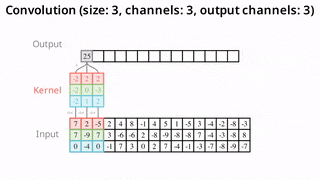

 We will typically also want to be able to apply our convolutions to multiple inputs at once, as in a batch. For this reason the `Conv2d` function in PyTorch actually expects 2 *4-dimensional tensors* with the following structure:

$$\text{Input: }\quad \text{Observations (N)} \times \text{Channels (c)} \times \text{Height (h)} \times \text{Width (w)}$$
$$\text{Kernel: }\quad \text{Output channels (o)} \times \text{Channels (c)} \times  \text{Size (s)} \times \text{Size (s)}$$

In this case, at each corresponding location between our input and kernel, we will multiply an $N \times c$ input matrix with the transpose of a $o \times c$ weight matrix to produce an $N \times o$ matrix. In total our result will have the following shape:

$$\text{Output: }\quad \text{Observations (N)} \times \text{Output channels (o)} \times \text{Output height (h)} \times \text{Output width (w)}$$

We can define each entry of the output with the following equation:

$$\text{Conv}(\mathbf{X}, \mathbf{K})_{n,k,r,c} =  \sum_{i=0}^{s-1}\sum_{j=0}^{s-1}\sum_{l=0}^{c-1} X_{n,l, r+i,c+j}\ K_{k, l, i,j}$$


#### **Q8** (5 Points)
Implement a new version of `conv2d` that takes in a *4-dimension* input array and a *4-dimensional* kernel array and computes the (batched) convolution function described above.

In [ ]:
def conv2d(image, kernel, padding=0):
    kernel_size = kernel.shape[-1]
    output_channels = kernel.shape[0]
    N, channels, image_height, image_width = image.shape[0], image.shape[1], image.shape[2], image.shape[3]
    output_height = # YOUR CODE HERE
    output_width = # YOUR CODE HERE

    output = np.zeros((N, output_channels, output_height, output_width))
    ## YOUR CODE HERE

    return output

PyTorch provides a convinient way to load *batches* of images from a dataset via the `DataLoader` class. The dataloader will automatically group images and labels into tensors for us!

In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(data,            # The dataset
                    batch_size=8,    # The batch size
                    shuffle=True,    # Tell PyTorch to randomize the order of the data
                    )

for batch in loader:
    images, labels = batch
    print('Image batch shape:', images.shape)
    print('Label batch shape:', labels.shape)
    break

Now we can try applying 3 kernels to a batch of data simultaniously.

In [ ]:
# Create an edge detection kernel
kernel = np.array([[ 1,  1,  1],
                   [ 0,  0,  0],
                   [-1, -1, -1]])
# Repeat it for the red, green and blue channels
kernel_vertical = np.stack([kernel])
# Create a transposed version as well
kernel_horizontal = np.stack([kernel.T])
# Create a blur kernel
kernel_blur = np.ones_like(kernel_horizontal)

# Put all 3 kernels together into a single array
kernel = np.stack([kernel_vertical, kernel_horizontal, kernel_blur])
output = conv2d(images, kernel)

# Create the axes for our plots
f, ax = plt.subplots(1, 5, figsize=(10, 3))
ax[0].imshow(images[0][0], cmap='Greys_r')
ax[0].set_title('Image')

# Plot the result of the first kernel
ax[1].imshow(output[0][0], cmap='Greys_r')
ax[1].set_title('Kernel 1')

# Plot the result of the second kernel
ax[2].imshow(output[0][1], cmap='Greys_r')
ax[2].set_title('Kernel 2')

# Plot the result of the third kernel
ax[3].imshow(output[0][2], cmap='Greys_r')
ax[3].set_title('Kernel 3')

# Plot the result of all three kernels as the rgb channels of an image
full_output = output[0].transpose(1, 2, 0)
full_output = full_output - full_output.min()
full_output = full_output / full_output.max()
ax[4].imshow(full_output)
ax[4].set_title('All kernels')

# Part 2: CNNs in PyTorch

The `nn` module from PyTorch includes built-in support for convolutional layers that we can use in the same way that we would use `nn.Linear` layers. In particular the `nn.Conv2d` layer will perform 2-dimensional convolutions over an image input. `nn.Conv2d` expects the input to have the *4-dimensional* shape we introduced above:

$$\text{Input: }\quad \text{Observations (N)} \times \text{Channels (c)} \times \text{Height (h)} \times \text{Width (w)}$$

A simple implementation of the `nn.Conv2d` module might look something like this:

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F


class Conv2D(nn.Module):
    def __init__(self, in_dimensions, out_dimensions, kernel_size):
        super().__init__()
        # Create a kernel (weight) parameter and a bias parameter
        self.kernel = nn.Parameter(torch.randn(out_dimensions, in_dimensions, kernel_size, kernel_size) / np.sqrt(in_dimensions))
        self.bias = nn.Parameter(torch.zeros((1, out_dimensions, 1, 1)))

    def forward(self, x):
        # The PyTorch equivalent of the conv2d function we wrote!
        print(x.shape, self.kernel.shape, self.bias.shape)
        return F.conv2d(x, self.kernel) + self.bias


We can use it as we would any other layer, as long as we give it the right input shape. Here we'll load an image into PyTorch and apply a very simple random convolution to it.

In [ ]:
output = Conv2D(1, 3, 3)(images)

# Convert to numpy
output = output.detach().numpy()

# Create the axes for our plots
f, ax = plt.subplots(1, 5, figsize=(10, 3))
ax[0].imshow(images[0][0], cmap='Greys_r')
ax[0].set_title('Image')

# Plot the result of the first kernel
ax[1].imshow(output[0][0], cmap='Greys_r')
ax[1].set_title('Kernel 1')

# Plot the result of the second kernel
ax[2].imshow(output[0][1], cmap='Greys_r')
ax[2].set_title('Kernel 2')

# Plot the result of the third kernel
ax[3].imshow(output[0][2], cmap='Greys_r')
ax[3].set_title('Kernel 3')

# Plot the result of all three kernels as the rgb channels of an image
full_output = output[0].transpose(1, 2, 0)
full_output = full_output - full_output.min()
full_output = full_output / full_output.max()
ax[4].imshow(full_output)
ax[4].set_title('All kernels')


Another important layer that we'll need for convolutional neural networks is the *max-pooling layer*. Recall that max-pooling is similar to a convolution, but rather than taking a dot product between a kernel and a window of the input, we simply take the maximum value in the window of an input. In the 1-dimensional case this looks like:

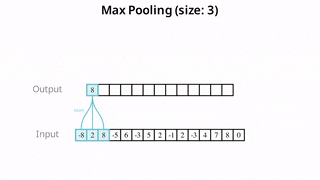

1-dimension max-pooling with a stride of 1 could be implemented as:

In [ ]:
def maxpool1d(sequence, pool_size=3):
    sequence_length = sequence.shape[0]
    output_length = sequence_length - pool_size + 1

    output = np.ones((output_length,)) * -np.inf
    for i in range(output_length):
        for k in range(pool_size):
            output[i] = np.maximum(output[i], sequence[i + k])
    return output

Recall that the *stride* of a pooling (or convolutional) layer specifies to take only 1 in every *stride* outputs. We can use this to *subsample* our sequence or image, producing a lower resolution version as shown below in 1-dimension.

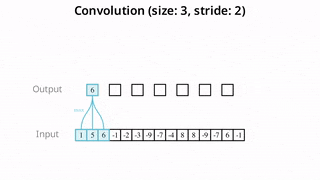

#### **Q9** (5 Points)

Modify the `maxpool1d` function above to take a `stride` argument. For example, if the output of a maxpool is:
$$\text{Output (stride 1): }\begin{bmatrix}5 & 1 & 7 & 4 & 3 & 8 & 2 & 9 & 6 \end{bmatrix}$$
Then the output with stride = 2 should be:
$$\text{Output (stride 2): }\begin{bmatrix}5  & 7  & 3  & 2 & 6 \end{bmatrix}$$
In gerneal the length of the output should be:
$\text{Size} \longrightarrow \big\lfloor\frac{\text{Size}}{\text{Stride}} \big\rfloor$

In [ ]:
def maxpool1d(sequence, pool_size=3, stride=1):
    sequence_length = sequence.shape[0]
    output_length = # YOUR CODE HERE

    output = np.ones((output_length,)) * -np.inf
    
    ## YOUR CODE HERE

    return output

In PyTorch we can use the `nn.MaxPool2D` layer to perform max-pooling within a neural network. We can perform the similar *average pooling* operation using `nn.AvgPool2D`. Average pooling simply takes the average over a window rather than the max. Below we show how to use both layers to lower the resolution of an image.

In [ ]:
# Create the axes for our plots
f, ax = plt.subplots(1, 5, figsize=(10, 3))
ax[0].imshow(images[0][0], cmap='Greys_r')
ax[0].set_title('Image')

# Plot the result of the first kernel
ax[1].imshow(nn.MaxPool2d(2, 1)(images)[0][0], cmap='Greys_r')
ax[1].set_title('Maxpool\n size=2, stride=1')

# Plot the result of the first kernel
ax[2].imshow(nn.MaxPool2d(2, 2)(images)[0][0], cmap='Greys_r')
ax[2].set_title('Maxpool\n size=2, stride=2')

# Plot the result of the first kernel
ax[3].imshow(nn.AvgPool2d(2, 1)(images)[0][0], cmap='Greys_r')
ax[3].set_title('Avgpool\n size=2, stride=1')

# Plot the result of the first kernel
ax[4].imshow(nn.AvgPool2d(2, 2)(images)[0][0], cmap='Greys_r')
ax[4].set_title('Avgpool\n size=2, stride=2')


The final new useful layer we'll introduce is the *flatten* layer, which is implemented in `nn.Flatten`. This layer takes in a *4-dimensional* batch of images and *flattens* it into *2-dimensional* matrix.

$$\text{Input: }\quad \text{Observations (N)} \times \text{Channels (c)} \times \text{Height (h)} \times \text{Width (w)}$$
$$ \longrightarrow \text{Output: }\quad \text{Observations (N)} \times \text{Total features } (chw)$$

We can implement a simple version of this layer as follows:


In [ ]:
class Flatten(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x.reshape(x.shape[:-3] + (-1,))


print('Shape of image batch:', images.shape)
print('Shape of flattened batch:', Flatten()(images).shape)

This flatten layer allows us to use `nn.Linear` layers following our convolutional layers.

We can now put everything together to make a very simple convolutional network with a single convolutional layer and a single linear layer:

In [ ]:
model = nn.Sequential(
    nn.Conv2d(1, 6, 5, padding=2),  # Convolutional layer with 1 input channel, 6 output channels and a kernel size of 5
    nn.Tanh(),                      # Tanh activation function
    nn.AvgPool2d(2, 2),             # Average pooling with a pool size of 2 and a stride of 2
    nn.Flatten(),                   # Flatten the output of AvgPool. to be batch x 1176
    nn.Linear(1176, 10),            # Final linear layer to predict 1 of 10 classes.
)

We'll use the provided `run_model` function (from the last homework) to train and evaluate this model on the FashionMNIST dataset.

In [ ]:
run_model(data_path, model)

Often convolutional neural network architectures are presented as diagrams that specify the size and number of convolutions at each layer. Below is a diagram describing one of the most famous convolutional neural network archtectures: LeNet-5 (named after on of it's inventors Yann LeCun).

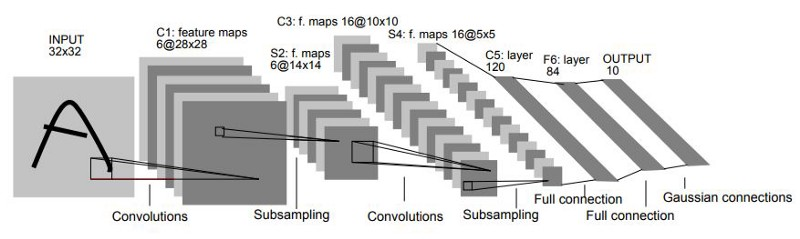

#### **Q10** (5 Points)

Implement a version of the LeNet-5 architecture shown above. Note that there are some crucial details missing from the figure, such as: the activation function to use and what kind of subsampling to use. Feel free to make your own choices for these. For activations you could use `nn.Tanh` or `nn.ReLU`. For subsampling you could use `nn.MaxPool2d` or `nn.AvgPool2d` with appropriate strides.

A few details to note:  


*  The size of our inputs is 28x28, not the 32x32 in the figure above, you'll need this information to compute the appropriate number of inputs for the first linear layer.
*   The kernel size is 5 for both convolutional layers.
*   "Subsampling" is a pooling and/or stride not an additional convolution.
*   In order to get the resolutions correct with a 28x28 input, you'll need to use `padding="same"` in the first convolutional layer and `padding="valid"` in the second.

In [ ]:
model = nn.Sequential(
    ## YOUR CODE HERE
)

run_model(data_path, model)

#### **Q11** (5 Points)

Now let's visualize a bit of what our network is doing.

Complete the code below to visualize both each of the 6 filters applied by the first convolutional layer of the model and each of the 6 channels of the output of the first layer.

In [ ]:
# Create the axes for our plots
f, ax = plt.subplots(2, 6, figsize=(12, 4))

# We're using a nn.Sequential model, so we can access the first layer as follows
layer = model[0]


## YOUR CODE HERE

#### **Q12** (5 Points)

Modify the network you just created such that the validation accuracy is as high as possible (ideally above 99\%). You may need to experiment a bit to find a network that works. Feel free to change the activations, the number and size of layers and the pooling. You may also use other layers that we've learned about, such as: `nn.Dropout` and `nn.BatchNorm2d`.

*If your LeNet-5 implementation already achieved over 99% accuracy, try to improve on its accuracy by a little. If it takes more than a few minutes to achieve over 99% accuracy, just make a note of what you tried and the best accuracy you got!*

In [ ]:
improved_model = nn.Sequential(
    ## YOUR CODE HERE
)

run_model(data_path, improved_model)

# Part 3: Autoencoders

As we've seen in class, an *autoencoder* is a special kind of neural network that is trained to output its input (or some modification of its input). Traditionally this network is split into 2 halves: an *encoder* that outputs a low-dimensional representation of the input, and a *decoder* that takes this low-dimensional representation and scales it back up to the original input size. 

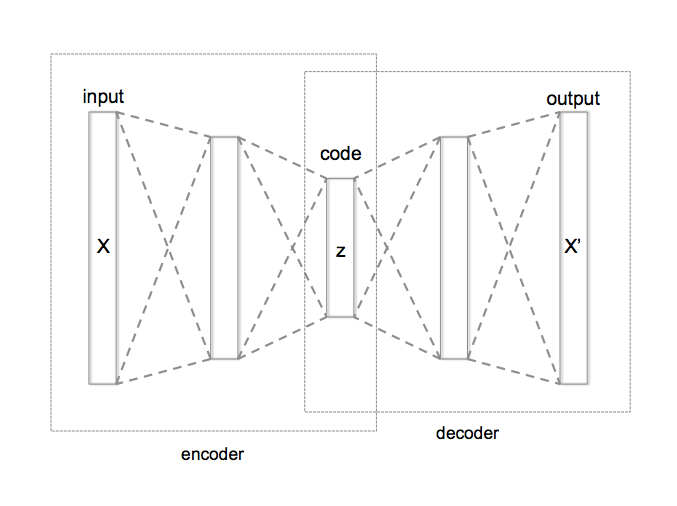

*from Wikipedia*

Because at the midpoint of the network we need to represent the entire input with a low-dimensional representation, we have what's known as an *information bottleneck*, that is, our decoded output can only make use of information that passes through this bottleneck. This makes autoencoders useful for compression, as if we have the decoder, we can approximately reconstruct any input from only the much smaller bottleneck representation.

Let's construct our own autoencoder! We'll start by reusing our LeNet network as our encoder, so our bottleneck dimension will be $10$. Feel free to make modifications to it for this section.

In [ ]:
encoder = model

#### **Q13** (10 Points)

Construct a *decoder* network that takes in a 10-dimensional input and outputs a $1 \times 28 \times 28$ image tensor. As a starting point, you should follow the same architecture as LeNet-5, but in reverse as shown below.

This means you'll need to (approximately) invert layers such as convolutions, average pooling and flattening. You can use the following substitutions going from your encoder to your decoder:

-   `nn.Conv2d` $\rightarrow$ `nn.ConvTranspose2d` **or** `nn.Conv2d` with padding
-   `nn.AvgPool2d` $\rightarrow$ `nn.Upsample`
-   `nn.Flatten` $\rightarrow$ `nn.Unflatten`

In [ ]:
decoder = nn.Sequential(
    ## YOUR CODE HERE
)

For convinience, we'll create an autoencoder model that lets us combine the encoder and decoder in to one object.  

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, X):
        return self.decoder(self.encoder(X))
    
ae_model = Autoencoder(encoder, decoder)

Now in order to train our model, we'll need to write some code for our training step. In this case we'll train our autoencoder with a *per-pixel mean squared error loss*:

$$\text{MSELoss}(X, w) = \frac{1}{N} \sum_{i=1}^N \sum_{j=1}^c \sum_{k=1}^h \sum_{l=1}^w \big( AE_w(X)_{ijkl} - X_{ijkl} \big)^2$$

All those summantions might look scary, but all we're doing is an element-wise operation between two tensors followed by a summation!

#### **Q14** (5 Points)

Complete the following function that takes in a model, an input image batch tensor, and a vector of labels (that we can ignore), and returns both the output from the autoencoder and the pixel-wise mean squared error loss.

In [ ]:
def autoencoder_output_and_mseloss(model, X,  y):
    '''
    Inputs:
        model: nn.Module, an autoencoder model.
        X: tensor (float), an N x C x H x W tensor of images
        y: tensor (float), an N x classes tensor of labels (unused)

    Outputs:
        output: tensor (float), an N x C x H x W tensor of reconstructed images.
        loss: float, the mean squared error loss between the input and reconstructions.
    '''
    
    ## YOUR CODE HERE
    return output, loss

With this function, we should now be able to train an autoencoder! (the `run_model` function accepts a function like this for computing the loss in training).

In [ ]:
get_output_and_loss = autoencoder_output_and_mseloss
run_model(data_path, ae_model, learning_rate=0.003, get_output_and_loss=get_output_and_loss)

And we can see what our trained reconstructions look like!

In [ ]:
output = ae_model(images)

# Convert to numpy
output = output.detach().numpy()

# Create the axes for our plots
f, ax = plt.subplots(4, 2, figsize=(4, 8))
for r in range(4):
    ax[r, 0].imshow(images[r][0], cmap='Greys_r')
    ax[r, 0].set_title('Image')
    ax[r, 0].axis('off')
    ax[r, 1].imshow(output[r][0], cmap='Greys_r')
    ax[r, 1].set_title('Reconstruction')
    ax[r, 1].axis('off')

Run the above training code. The results will depend on exactly how you modified the networks before, but they probably don't look great! Ideally our reconstructions would look a lot like our original images.

#### **Q15** (10 Points)

In the cell below, modify the architecture of your encoder and decoder networks to improve the performance.

*Think about what prevents reconstructions from being good and how you might loosen any restrictions that affect this performance. Don't forget the goals of an autoencoder as you do this. The ideal solution should be a balance between compression and reconstruction performance.*

In [ ]:
encoder = nn.Sequential(
    ## YOUR CODE HERE                              
)

decoder = nn.Sequential(
    ## YOUR CODE HERE
)

ae_model = Autoencoder(encoder, decoder)
run_model(data_path, ae_model, learning_rate=0.003, get_output_and_loss=autoencoder_output_and_maeloss)

Now we can see what our trained reconstructions look like.

In [ ]:
output = ae_model(images)

# Convert to numpy
output = output.detach().numpy()

# Create the axes for our plots
f, ax = plt.subplots(4, 2, figsize=(4, 8))
for r in range(4):
    ax[r, 0].imshow(images[r][0], cmap='Greys_r')
    ax[r, 0].set_title('Image')
    ax[r, 0].axis('off')
    ax[r, 1].imshow(output[r][0], cmap='Greys_r')
    ax[r, 1].set_title('Reconstruction')
    ax[r, 1].axis('off')

Let's now consider some neat things we can do with our autoencoder model! We'll start with image interpolation, that is, lets try to smoothly transition from one image to another. 

An easy standard for interpolation is *linear interpolation*. If we want to find intermediates between starting and ending values, $x^{(0)}$ and $x^{(1)}$, we'll assing intermediate value $x^{(t)}$ for $t\in[0, 1]$ as:

$$x^{(t)} = t\cdot x^{(1)} + (1-t)\cdot x^{(0)}$$

We can do this pixel-by-pixel to transition from one image to another as shown below!

In [ ]:
image_0 = images[2, 0] # Select image 0 and remove unused channel dimension
image_1 = images[1, 0] # Same for second image

f, ax = plt.subplots(1, 10, figsize=(15, 1.5))
for i, t in enumerate(np.linspace(0, 1, 10)):
    # Perform the interpolation and show each intermediate result.
    image_t = t * image_1 + (1 - t) * image_0
    ax[i].imshow(image_t, cmap='Greys_r')

We can see that, while this works, it's a bit unsatisfying. One image "ghosts" into another rather than reshaping as we might desire. Let's see if our autoencoder can help! Instead of interpolating pixels, let's try interpolating our compressed representations. In this case, we'll use the following interpolation:

$$\mathbf{x}^{(t)} = \text{decoder}\big( t\cdot \text{encoder}(\mathbf{x}^{(1)}) + (1-t)\cdot \text{encoder}( \mathbf{x}^{(0)})\big)$$

#### **Q16** (5 Points)

Modify the interpolation code to use interpolation in the "latent" compressed representation as shown above.

In [ ]:
image_0 = images[2, 0] # Select image 0 and remove unused channel dimension
image_1 = images[1, 0] # Same for second image

f, ax = plt.subplots(1, 10, figsize=(15, 1.5))
for i, t in enumerate(np.linspace(0, 1, 10)):
    # Perform the interpolation and show each intermediate result.
    
    image_t = ## YOUR CODE HERE
    ax[i].imshow(image_t, cmap='Greys_r')

What do you notice about the output here?

YOUR ANSWER HERE

## Part 3: Maximum Likelihood Training

### Background:
Let's step away from autoencoders for a minute and go back to our old friend linear regression. In the linear regression setting we're trying to predict a continuous label $y_i \in \mathbb{R}$ from an input vector $\mathbf{x}_i \in \mathbb{R}^d$. Recall that we can view linear regression as the following probibalistic model:
$$
y_i \sim \mathcal{N}\big(\mathbf{x}_i^T \mathbf{w},\ \sigma^2\big)
$$
Where $\mathcal{N}(\mu, \sigma)$ is the *Normal distribution*, which has the following probability density function:
$$
p(y\mid \mu, \sigma) = \frac{1}{\sigma \sqrt{2 \pi}} \text{exp}\bigg(-\frac{1}{2\sigma^2} (y -\mu)^2\bigg)
$$
We saw that a reasonable way to choose the optimal $\mathbf{w}$ is to *maximize the likelihood* of our observed dataset, which is equivalent to *minimizing the negative log likelihood*:
$$\underset{\mathbf{w}}{\text{argmax}} \prod_{i=1}^N p(y_i\mid \mathbf{x}_i, \mathbf{w}, \sigma) =
\underset{\mathbf{w}}{\text{argmin}} -\sum_{i=1}^N \log p(y_i\mid \mathbf{x}_i, \mathbf{w}, \sigma) = \underset{\mathbf{w}}{\text{argmin}}\ \frac{1}{2\sigma^2}\sum_{i=1}^N  (y_i -\mathbf{x}_i^T\mathbf{w})^2 + C
$$
Where $C$ is a constant: $C = N \log \sigma \sqrt{2\pi}$. We further saw that this is equivalent to minimizing the *mean squared error* for any choice of $\sigma$.

### Laplace Maximum Likelihood Estimation

A natural question about the above model is: why choose the Normal distribution? In principal, we could define a linear model using *any* distribution over the real numbers $\mathbb{R}$. Let's explore an alternative choice: the *Laplace distribution* ([Wiki](https://en.wikipedia.org/wiki/Laplace_distribution)). The Laplace distribution $L(\mu, a)$ has the following PDF:

$$p(y\mid \mu, a) = \frac{1}{2a} \exp\bigg(- \frac{|y-\mu|}{a} \bigg) $$

As for the normal distribution $\mu$ is the mean, while $a$ defines the "width" of the distribution (analogous to variance for the Normal). We can compare the two distributions visually:

In [ ]:
ylp = np.linspace(-3, 3, 200)
mu, sigma2_or_a = 0, 1
p_y_normal = (1 / np.sqrt(sigma2_or_a * 2 * np.pi)) * np.exp(- (0.5 / sigma2_or_a) * (ylp - mu) ** 2)
p_y_laplace = (1 / (2 * sigma2_or_a)) * np.exp(- (1 / sigma2_or_a) * np.abs(ylp - mu))

plt.figure(figsize=(4,3))
plt.plot(ylp, p_y_normal, label=r"Normal PDF")
plt.plot(ylp, p_y_laplace, label=r"Laplace PDF")
plt.xlabel('$y$')
plt.ylabel('$p(y)$')
plt.legend()
pass

Let's now consider the Laplace version of our probabilistic linear model:
$$
y_i \sim L\big(\mathbf{x}_i^T \mathbf{w},\ a\big)
$$
Recall that the negative log-likelihood is defined as:
$$\mathbf{NLL}(\mathbf{w}, a, \mathbf{X}, \mathbf{y}) = -\sum_{i=1}^N \log p(y_i\mid \mathbf{x}_i, \mathbf{w}, a)$$

#### **Q17** (5 points)
Write out the negative log-likelihood for this model in terms of $\mathbf{w}, a, \mathbf{X}, y$ using the Laplace PDF shown above.

**YOUR ANSWER HERE**
$$\mathbf{NLL}(\mathbf{w}, a, \mathbf{X}, \mathbf{y}) = $$

Note that if we drop the constants, we would call this loss the *sum absolute error*.

#### **Q18** (10 points)
Find the gradient with respect to $\mathbf{w}$ of the negative log-likelihood for this model. *Hint: remember that the gradient is the vector of partial derivatives!*

You should use the following definition of the derivative of the absolute value $|\cdot |$ operator:
$$\frac{d}{dx}|x| = sign(x), \quad sign(x) = \begin{cases} +1 \quad \text{ if  } x > 0 \\ -1 \quad \text{ if  } x < 0 \\ \ \ \ 0 \quad \text{ if  } x = 0 \end{cases}$$
(Technically $\frac{d}{dx}|x|$ is undefined at $x=0$, but it is convinient to assume $\frac{d}{dx}|0|=0$ in practice.)

**YOUR ANSWER HERE**
$$\nabla_{\mathbf{w}}\mathbf{NLL}(\mathbf{w}, b, \mathbf{X}, \mathbf{y}) = $$

We see that this Laplace model gives us a probabilistic justification for *absolute error*, which again is similar to squared error, but replacing the square with an absolute value. We can use this in place of squared error anywhere we want!

Let's go back to our autoencoder model and try using a *per-pixel mean **absolute** error* in place of the mean squared error we used before.

$$\text{MAELoss}(X, w) = \frac{1}{N} \sum_{i=1}^N \sum_{j=1}^c \sum_{k=1}^h \sum_{l=1}^w \big| AE_w(X)_{ijkl} - X_{ijkl} \big|$$



#### **Q19** (5 Points)

Complete the following function that takes in a model, an input image batch tensor, and a vector of labels (that we can ignore), and returns both the output from the autoencoder and the pixel-wise mean absolute error loss.

In [ ]:
def autoencoder_output_and_maeloss(model, X,  y):
    '''
    Inputs:
        model: nn.Module, an autoencoder model.
        X: tensor (float), an N x C x H x W tensor of images
        y: tensor (float), an N x classes tensor of labels (unused)

    Outputs:
        output: tensor (float), an N x C x H x W tensor of reconstructed images.
        loss: float, the mean squared error loss between the input and reconstructions.
    '''
    
    ## YOUR CODE HERE
    return output, loss

Now we can compare these two losses!

In [ ]:
get_output_and_loss = autoencoder_output_and_maeloss# MSE or MAE
run_model(data_path, ae_model, learning_rate=0.003, get_output_and_loss=get_output_and_loss)

output = ae_model(images)

# Convert to numpy
output = output.detach().numpy()

# Create the axes for our plots
f, ax = plt.subplots(4, 2, figsize=(4, 8))
for r in range(4):
    ax[r, 0].imshow(images[r][0], cmap='Greys_r')
    ax[r, 0].set_title('Image')
    ax[r, 0].axis('off')
    ax[r, 1].imshow(output[r][0], cmap='Greys_r')
    ax[r, 1].set_title('Reconstruction')
    ax[r, 1].axis('off')

#### **Q20** (10 Points)

Run the above training code with both the MSE and MAE losses. (You'll also need to re-run any cells that setup the network in order to re-initialize the weights).

Which loss gave better results from your perspective? Give an explanation for why the chosen loss produced better results.

YOUR ANSWER HERE

#### Conclusion

At this point you're probably a bit confused about the connection between this negative log-likelihood idea and autoencoders. After all, we're doing something pretty different from linear regression. However, let's think about our autoencoder just from the perspective of the decoder (perhaps assuming that our encoder is just given to us). 

From the decoder's perspective, our training data is a set of pairs of low-dimensional embeddings ($\mathbf{z}\in \mathbb{R}^b$) and high-dimensional images ($\mathbf{X}\in \mathbb{R}^d$) : 

$$(\mathbf{z}_1, \mathbf{x}_1), (\mathbf{z}_2, \mathbf{x}_2) ... (\mathbf{z}_N, \mathbf{x}_N)$$

Our goal is simply to predict $\mathbf{x}_i$ from $\mathbf{z}_i$, which is essentially a regression problem! Therefore we can think about it in terms of a probalistic model:

$$p(\mathbf{x}_i \mid \mathbf{z}_i, \mathbf{w})$$

For simplicity, we'll usually assume *conditional independence* between the dimensions (pixels) of $\mathbf{x}$, so we'll say:

$$p(\mathbf{x}_i \mid \mathbf{z}_i, \mathbf{w}) = \prod_{j=1}^c \prod_{k=1}^h \prod_{l=1}^w p(x_{ijkl} \mid \mathbf{z}_i, \mathbf{w})$$


Now we're free to use a Normal, Laplace or any other distribution we want for these conditionals! For example we might say:

$$p(x_{ijkl} \mid \mathbf{z}_i, \mathbf{w}) = \mathcal{N}(\text{decoder}\big(\mathbf{z}_i)_{jkl}, \sigma\big)$$

or

$$p(x_{ijkl} \mid \mathbf{z}_i, \mathbf{w}) = \text{Laplace}(\text{decoder}\big(\mathbf{z}_i)_{jkl}, a\big)$$

Later in this course we'll see how we can extend this idea to make a model that generates new images!